In [1]:
import os
# ! pip install librosa
# ! pip install xgboost
import librosa
import xgboost as xgb
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GroupKFold
import joblib

In [ ]:
# define folder paths
real_folder_song_path = os.path.normpath(r"D:\LING_199_audio\sonics-archive\real_songs")
fake_folder_song_path = os.path.normpath(r"D:\LING_199_audio\sonics-archive\fake_songs")

real_folder_speech_path = os.path.normpath(r"D:\LING_199_audio\for-2sec-archive\real_speech")
fake_folder_speech_path = os.path.normpath(r"D:\LING_199_audio\for-2sec-archive\fake_speech")

In [ ]:
# list length of each song folder
real_files = os.listdir(real_folder_song_path)
fake_files = os.listdir(fake_folder_song_path)

print(f"Number of real files: {len(real_files)}")
print(f"Number of fake files: {len(fake_files)}")

In [4]:
# bad sample: fake_00001_suno_1.mp3
# good sample: fake_00061_suno_1.mp3

# load an audio sample
y, sr = librosa.load(os.path.join(fake_folder_song_path, "fake_00061_suno_1.mp3"), sr=16000)
print(f"Audio sample rate: {sr}")

Audio sample rate: 16000


In [5]:
# play the audio interactively
import IPython.display as ipd
ipd.Audio(y, rate=sr)

In [ ]:
def extract_and_save_features(real_folder, fake_folder, save_path, num_sampled_seconds=120, song=False, num_sampled_files=100):
    """
    Loads audio from real and fake folders, extracts features from a random sample of up to 100 files per folder,
    and from each file extracts features from up to sample_count random 1-second segments.
    Labels them, saves to CSV, and returns the combined DataFrame.

    Parameters:
    real_folder (str): Path to the folder containing real audio files.
    fake_folder (str): Path to the folder containing fake audio files.
    save_path (str): Path to save the CSV file.
    sample_count (int): Number of 1-second segments to sample from each file.
    song (bool): If True, label the data as song (1) or not (0).
    
    Returns:
    pd.DataFrame: DataFrame containing the extracted features and labels.
    """

    all_data = []
    song_label = 1 if song else 0

    # Iterate over both folders (real and fake) and assign deepfake label 0 or 1
    for folder_path, deepfake_label in [(real_folder, 0), (fake_folder, 1)]:
        processed_files = 0
        # Get a random sample of up to 'num_sampled_files' filenames from the current folder
        all_files = os.listdir(folder_path)
        sampled_files = random.sample(all_files, min(num_sampled_files, len(all_files)))

        for filename in sampled_files:
            file_path = os.path.join(folder_path, filename)
            print(f"Processing {file_path}...")

            try:
                y, sr = librosa.load(file_path, sr=None)
                total_seconds = len(y) // sr

                if total_seconds < 1:
                    continue  # skip files that are too short

                # randomly sample 'sampled_seconds' unique second indexes, or fewer if audio is too short
                seconds_to_sample = min(num_sampled_seconds, total_seconds)
                sampled_seconds = random.sample(range(total_seconds), seconds_to_sample)

                for sec in sampled_seconds:
                    y_slice = y[sec*sr : (sec+1)*sr]
                    try:
                        chromagram = librosa.feature.chroma_stft(y=y_slice, sr=sr)
                        rms = librosa.feature.rms(y=y_slice)
                        spectral_centroid = librosa.feature.spectral_centroid(y=y_slice, sr=sr)
                        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y_slice, sr=sr)
                        rolloff = librosa.feature.spectral_rolloff(y=y_slice, sr=sr)
                        zero_crossing_rate = librosa.feature.zero_crossing_rate(y_slice)
                        mfcc = librosa.feature.mfcc(y=y_slice, sr=sr, n_mfcc=20)

                        feature_row = {
                            'chroma_stft': chromagram.mean(),
                            'rms': rms.mean(),
                            'spectral_centroid': spectral_centroid.mean(),
                            'spectral_bandwidth': spectral_bandwidth.mean(),
                            'rolloff': rolloff.mean(),
                            'zero_crossing_rate': zero_crossing_rate.mean(),
                            **{f'mfcc{i+1}': mfcc[i].mean() for i in range(20)},
                            'deepfake': deepfake_label,
                            'song': song_label
                        }
                        all_data.append(feature_row)
                    except Exception as fe:
                        print(f"Feature extraction error in {file_path} (second {sec}): {fe}")

            except Exception as e:
                print(f"Error loading {file_path}: {e}")
            
            # print number of files processed
            processed_files += 1
            print(f"Processed {processed_files}/{len(os.listdir(folder_path))} files in {'real folder' if deepfake_label == 0 else 'fake folder'}.")

    df = pd.DataFrame(all_data)
    if save_path:
        print(f"Saving dataset to {save_path}...")
        df.to_csv(save_path, index=False)
    else:
        print("No save path provided, not saving dataset.")
    return df

In [ ]:
# use the function to extract features and save to CSV
# each song file will be sampled for 120 seconds, and each speech file will be sampled for 2 seconds
song_df = extract_and_save_features(real_folder_song_path, fake_folder_song_path, r"D:\LING_199_audio\csv\song_dataset.csv", song=True, num_sampled_files=3212)
speech_df = extract_and_save_features(real_folder_speech_path, fake_folder_speech_path, r"D:\LING_199_audio\csv\speech_dataset.csv", song=False, num_sampled_files=30000)

Processing D:\LING_199_audio\sonics-archive\real_songs\mirrorball (the long pond studio sessions).mp3...
Processed 1 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\Halsey - Bad At Love.mp3...


c:\Users\ivani\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processed 2 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\Hotel California (2013 Remaster).mp3...
Processed 3 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\Bruno Mars - Count on Me (Official Lyric Video).mp3...
Processed 4 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\Rock the Casbah (Bob Clearmountain Mix).mp3...
Processed 5 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\And the Snakes Start to Sing.mp3...
Processed 6 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\Joyner Lucas - Bank Account (Remix).mp3...
Processed 7 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\Loving Someone.mp3...
Processed 8 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\Adele - Rolling in the Deep (Official Music Video).mp3...
Processed 9 files for real folder.
Processing D:\LING_199_audio\sonic

C:\Users\ivani\AppData\Local\Temp\ipykernel_5756\1091912180.py:34: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
c:\Users\ivani\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error loading D:\LING_199_audio\sonics-archive\real_songs\FEEL..mp4.part: 
Processed 226 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\Ice Cream Man (Sped Up).mp3...
Processed 227 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\TROLLZ (with Nicki Minaj).mp3...
Processed 228 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\Gin and Juice.mp3...
Processed 229 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\betty.mp3...
Processed 230 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\For the First Time in Forever (Reprise).mp3...
Processed 231 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\Lizzo - Cuz I Love You (Official Video).mp3...
Processed 232 files for real folder.
Processing D:\LING_199_audio\sonics-archive\real_songs\One Day.mp3...
Processed 233 files for real folder.
Processing D:\LING_199_audio\sonics-a

In [ ]:
# concatenate the two dataframes
combined_df = pd.concat([song_df, speech_df], ignore_index=True)

# save the combined dataframe to a CSV file
combined_df.to_csv(r"D:\LING_199_audio\csv\combined_dataset.csv", index=False)

In [2]:
# load in song df
song_df = pd.read_csv(r"C:\Users\ivani\OneDrive\Desktop\LING_199_hard_drive\data\song_dataset.csv")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters found: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 200}
Deepfake Model Test Accuracy: 0.9998570261437908


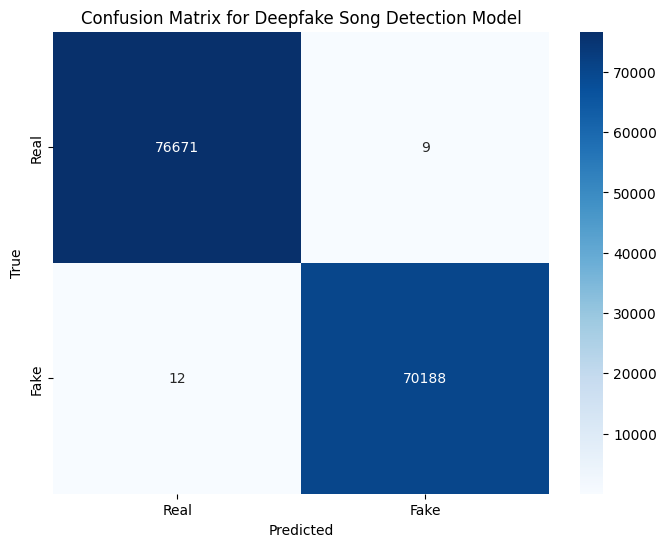

In [ ]:
'''
Train a deepfake xgboost model on the deepfake data (model will detect if the audio is real or fake)
'''

# drop the 'song' column from the combined dataframe
deepfake_model_data = song_df.drop(columns=['song'])

# Separate predictors and target label ('deepfake')
X = deepfake_model_data.drop(columns=['deepfake'])
y = deepfake_model_data['deepfake']

# Normalize each predictor
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# save the fitted scaler to a file for later use
joblib.dump(scaler, r"C:\Users\ivani\OneDrive\Desktop\LING_199_hard_drive\scaler.joblib")

# Determine the number of complete songs (each song has 120 seconds of data)
n_complete = X_scaled.shape[0] // 120
n_rows = n_complete * 120

# Restrict data to complete songs only
X_scaled = X_scaled[:n_rows]
y = y.iloc[:n_rows]

# Create groups array for complete data
groups = np.repeat(np.arange(n_complete), 120)

# Use GroupKFold to ensure that all samples from the same song are in the same fold
gkf = GroupKFold(n_splits=5)
for train_idx, test_idx in gkf.split(X_scaled, y, groups):
    X_train = X_scaled[train_idx]
    X_test = X_scaled[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    break  # use the first fold as our defined split

# Slice groups for the training set
groups_train = groups[train_idx]

# Define an XGBoost classifier
xgb_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

# Define an expanded tuning grid
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    # 'early_stopping_rounds': [10, 20, 30],
    # 'subsample': [0.5, 0.7, 1.0],
    # 'colsample_bytree': [0.5, 0.7, 1.0],
    # 'gamma': [0, 0.1, 0.2],
    # 'min_child_weight': [1, 2, 3],
    # 'scale_pos_weight': [1, 2, 3],
    # 'reg_alpha': [0, 0.1, 0.5],
    # 'reg_lambda': [1, 1.5, 2],
}

# Perform grid search with cross-validation, grouped by song (every 120 rows of data)
grid_search = GridSearchCV(xgb_clf, param_grid, cv=gkf, n_jobs=-1, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train, groups=groups_train)

print("Best parameters found:", grid_search.best_params_)

# Training with the best estimator
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Deepfake Model Test Accuracy:", accuracy)

# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Deepfake Song Detection Model')
plt.show()

# Shap importance for xgboost song model

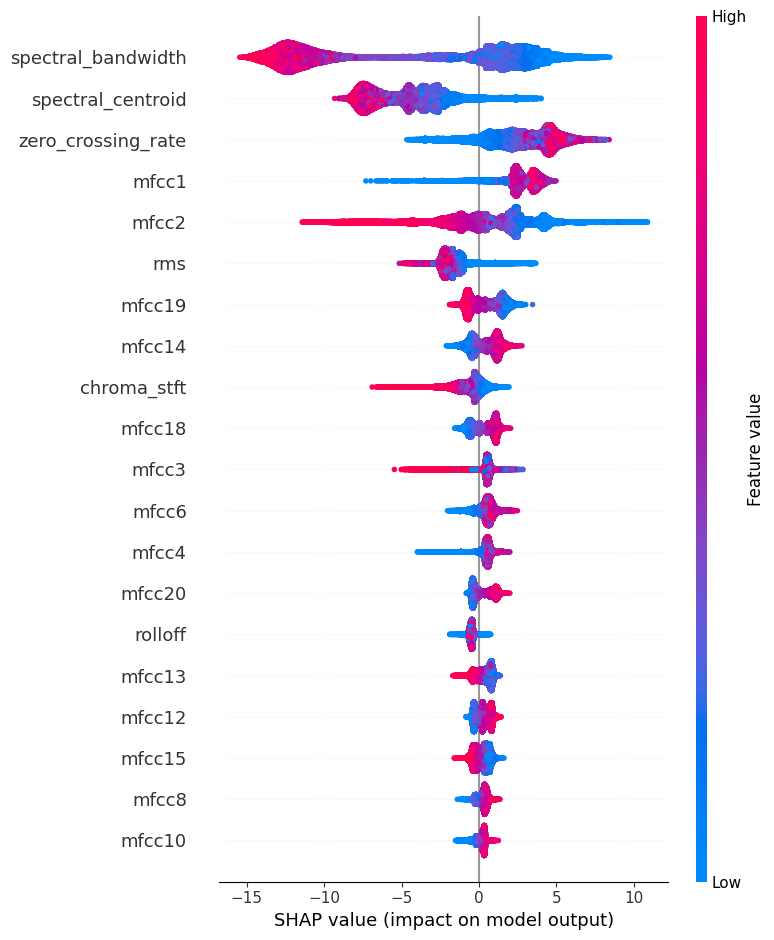

In [3]:
import shap
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold

# drop the 'song' column from the combined dataframe
deepfake_model_data = song_df.drop(columns=['song'])

# Separate predictors and target label ('deepfake')
X = deepfake_model_data.drop(columns=['deepfake'])
y = deepfake_model_data['deepfake']

# Normalize each predictor
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert back to DataFrame to preserve column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Determine the number of complete songs (each song has 120 seconds of data)
n_complete = X_scaled_df.shape[0] // 120
n_rows = n_complete * 120

# Restrict data to complete songs only
X_scaled_df = X_scaled_df.iloc[:n_rows, :]
y = y.iloc[:n_rows]

# Create groups array for complete data
groups = np.repeat(np.arange(n_complete), 120)

# Use GroupKFold to ensure that all samples from the same song are in the same fold
gkf = GroupKFold(n_splits=5)
for train_idx, test_idx in gkf.split(X_scaled_df, y, groups):
    X_train = X_scaled_df.iloc[train_idx, :]
    X_test = X_scaled_df.iloc[test_idx, :]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    break  # use the first fold as our defined split

# Slice groups for the training set (if needed)
groups_train = groups[train_idx]

# load the best model (xgboost Booster format)
model = xgb.Booster()
model.load_model(r"C:\Users\ivani\OneDrive\Desktop\LING_199_hard_drive\deepfake_song_model1.json")

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)  # X_test is now a DataFrame with feature names
shap.summary_plot(shap_values, X_test, plot_type="dot")

In [ ]:
def predict_audio(file_path, model, scaler):
    """
    Predict if the audio file is real or fake by extracting 1-second segments,
    getting the tree confidence (predicted probability) for each segment, and then 
    aggregating (averaging) them. It returns the final prediction along with the average probability.

    Parameters:
    file_path (str): Path to the audio file.
    model: Trained XGBoost model.
    scaler: StandardScaler object used for scaling features.

    Returns:
    tuple: (final_pred, avg_prob) where final_pred is 0 (real) or 1 (fake), and avg_prob is the aggregated probability.
    """
    y, sr = librosa.load(file_path, sr=16000)
    total_seconds = len(y) // sr

    if total_seconds < 1:
        print("Audio file is too short.")
        return None

    probabilities = []  # Each element is the predicted probability for the fake class for a 1-second segment

    # Loop over every second of the audio
    for sec in range(total_seconds):
        y_slice = y[sec*sr : (sec+1)*sr]
        
        # Extract features for this 1-second segment
        chromagram = librosa.feature.chroma_stft(y=y_slice, sr=sr).mean()
        rms = librosa.feature.rms(y=y_slice).mean()
        spectral_centroid = librosa.feature.spectral_centroid(y=y_slice, sr=sr).mean()
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y_slice, sr=sr).mean()
        rolloff = librosa.feature.spectral_rolloff(y=y_slice, sr=sr).mean()
        zero_crossing_rate = librosa.feature.zero_crossing_rate(y_slice).mean()
        mfcc = librosa.feature.mfcc(y=y_slice, sr=sr, n_mfcc=20)
        
        feature_row = {
            'chroma_stft': chromagram,
            'rms': rms,
            'spectral_centroid': spectral_centroid,
            'spectral_bandwidth': spectral_bandwidth,
            'rolloff': rolloff,
            'zero_crossing_rate': zero_crossing_rate,
            **{f'mfcc{i+1}': mfcc[i].mean() for i in range(20)}
        }
        
        feature_df = pd.DataFrame([feature_row])
        feature_scaled = scaler.transform(feature_df)
        
        # Use predict_proba which returns the aggregated tree confidence for each segment
        prob = model.predict_proba(feature_scaled)[0][1]
        probabilities.append(prob)
    
    # Average the predicted probabilities over all segments
    avg_prob = np.mean(probabilities)
    # Your final prediction uses 0.5 as threshold
    final_pred = 1 if avg_prob >= 0.5 else 0

    return final_pred, avg_prob, feature_df

# Example usage:
# file_path = r"C:\Users\ivani\Downloads\Color Your Night [ ezmp3.cc ].mp3"
file_path = r"C:\Users\ivani\Downloads\Electric Heartbeat.mp3"
# file_path = r"D:\LING_199_audio\sonics-archive\fake_songs\fake_54340_suno_1.mp3"

# load a previously saved model
best_model = xgb.XGBClassifier()
best_model.load_model(r"C:\Users\ivani\OneDrive\Desktop\LING_199_hard_drive\deepfake_song_model1.json")

# load scaler
import joblib
scaler = joblib.load(r"C:\Users\ivani\OneDrive\Desktop\LING_199_hard_drive\scaler.joblib")

prediction, confidence, feature_df = predict_audio(file_path, best_model, scaler)

print(f"Prediction for {file_path}: {'Fake' if prediction == 1 else 'Real'}")
print("Average probability (confidence) for fake class: {:.2f}%".format(confidence * 100))

Prediction for C:\Users\ivani\Downloads\I Ain't Gay.mp3: Fake
Average probability (confidence) for fake class: 99.85%


In [ ]:
# save the model
model_path = os.path.normpath(r"D:\LING_199_audio\trained_models\deepfake_song_model1.json")
# best_model.save_model(model_path)

In [ ]:
# train a song xgboost model on the song data (model will detect if the audio is a song or not)

# drop the 'deepfake' column from the combined dataframe

song_model_data = combined_df.drop(columns=['deepfake'])

# Separate predictors and target label ('song')
X = song_model_data.drop(columns=['song'])
y = song_model_data['song']

# Normalize each predictor
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Define an XGBoost classifier for song detection
xgb_song_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

# Define a tuning grid to find the best parameters
param_grid_song = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2, 0.3]
}

# Use cross-validation to find the best parameters via GridSearchCV (10-fold CV)
grid_search_song = GridSearchCV(xgb_song_clf, param_grid_song, cv=10, n_jobs=-1, scoring='accuracy', verbose=1)
grid_search_song.fit(X_train, y_train)

print("Best parameters for song model:", grid_search_song.best_params_)

# Use the best parameters to train the song model
best_song_model = grid_search_song.best_estimator_
best_song_model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred_song = best_song_model.predict(X_test)
accuracy_song = accuracy_score(y_test, y_pred_song)
print("Song Model Test Accuracy:", accuracy_song)

Fitting 10 folds for each of 64 candidates, totalling 640 fits
Best parameters for song model: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 200}
Song Model Test Accuracy: 0.9946819825569028


In [ ]:
# save the model
song_model_path = os.path.normpath(r"D:\LING_199_audio\trained_models\song_model1.json")
best_song_model.save_model(song_model_path)

In [21]:
import os
import yt_dlp
import pandas as pd

def download_youtube_video(video_url, download_path):
    """
    Downloads a single YouTube video and converts it to mp3 format.
    
    Parameters:
    video_url (str): URL of the YouTube video.
    download_path (str): Local path to save the downloaded mp3 file.
    """
    ydl_opts = {
        'format': 'bestaudio/best',
        'extractaudio': True,
        'audioformat': 'mp3',
        # use the title in the output template
        'outtmpl': os.path.join(download_path, '%(title)s.%(ext)s'),
        'noplaylist': True,  # Only download a single video
        'ffmpeg_location': r"C:\Users\ivani\Downloads\ffmpeg-2025-05-19-git-c55d65ac0a-essentials_build\bin",
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'mp3',
            'preferredquality': '192',
        }],
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        try:
            # Get video information without downloading
            info = ydl.extract_info(video_url, download=False)
            # Sanitize the title to use as filename
            title = yt_dlp.utils.sanitize_filename(info.get('title', 'video'))
            file_path = os.path.join(download_path, f"{title}.mp3")
            
            # if the file already exists, skip downloading
            if os.path.exists(file_path):
                print(f"File already exists: {video_url}")
                return
            
            # Download and convert the video to mp3
            ydl.download([video_url])
            print(f"Downloaded and converted video from {video_url} to mp3 format in {download_path}")
        
        # Handle errors and skip the video if it fails
        except Exception as e:
            print(f"Error downloading {video_url}: {e}")

'''Example usage'''
id_list = pd.read_csv(os.path.normpath(r"D:\LING_199_audio\sonics-archive\real_songs.csv"))['youtube_id'].tolist()

# get the number of files in the real songs directory
real_songs_count = len(os.listdir(real_folder_song_path))

# index the list of IDs to start from length of the real songs directory
id_list = id_list[real_songs_count:]

# iterate over the list of IDs
for id in id_list:
    video_url = f'https://www.youtube.com/watch?v={id}'
    download_path = r"D:\LING_199_audio\sonics-archive\real_songs"
    download_youtube_video(video_url, download_path)

[youtube] Extracting URL: https://www.youtube.com/watch?v=Kh3_Mn1wncE
[youtube] Kh3_Mn1wncE: Downloading webpage
[youtube] Kh3_Mn1wncE: Downloading tv client config
[youtube] Kh3_Mn1wncE: Downloading tv player API JSON
[youtube] Kh3_Mn1wncE: Downloading ios player API JSON
[youtube] Kh3_Mn1wncE: Downloading m3u8 information
[youtube] Extracting URL: https://www.youtube.com/watch?v=Kh3_Mn1wncE
[youtube] Kh3_Mn1wncE: Downloading webpage
[youtube] Kh3_Mn1wncE: Downloading tv client config
[youtube] Kh3_Mn1wncE: Downloading tv player API JSON
[youtube] Kh3_Mn1wncE: Downloading ios player API JSON
[youtube] Kh3_Mn1wncE: Downloading m3u8 information
[info] Kh3_Mn1wncE: Downloading 1 format(s): 251
[download] Destination: D:\LING_199_audio\sonics-archive\real_songs\Heaven Or Las Vegas.webm
[download] 100% of    5.43MiB in 00:00:00 at 15.32MiB/s  
[ExtractAudio] Destination: D:\LING_199_audio\sonics-archive\real_songs\Heaven Or Las Vegas.mp3
Deleting original file D:\LING_199_audio\sonics-arch

         n = 1QUNnrCFgNdxPKiM4MqA ; player = https://www.youtube.com/s/player/59b252b9/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U
         n = M3CYJHSONO6BmHQUsT3Q ; player = https://www.youtube.com/s/player/59b252b9/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U
         n = ss-mg15-RoE4HaNwFbT- ; player = https://www.youtube.com/s/player/59b252b9/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U
         n = -qVf9r9CCZXCXP1ua2Ci ; player = https://www.youtube.com/s/player/59b252b9/player_ias

[youtube] Ar2XQLvGwzQ: Downloading m3u8 information
[youtube] Extracting URL: https://www.youtube.com/watch?v=Ar2XQLvGwzQ
[youtube] Ar2XQLvGwzQ: Downloading webpage
[youtube] Ar2XQLvGwzQ: Downloading tv client config
[youtube] Ar2XQLvGwzQ: Downloading tv player API JSON
[youtube] Ar2XQLvGwzQ: Downloading ios player API JSON


         n = R8UbFQ1ZqnCzv7JDTXq5 ; player = https://www.youtube.com/s/player/59b252b9/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U
         n = _2bG7eDNlTIApptB_MZA ; player = https://www.youtube.com/s/player/59b252b9/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U
         n = oaVxzlav0P-vGYuXROzz ; player = https://www.youtube.com/s/player/59b252b9/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U
         n = AixiGa_QzBjjDXiq-JCV ; player = https://www.youtube.com/s/player/59b252b9/player_ias

[youtube] Ar2XQLvGwzQ: Downloading m3u8 information
[info] Ar2XQLvGwzQ: Downloading 1 format(s): 234
[hlsnative] Downloading m3u8 manifest
[hlsnative] Total fragments: 54
[download] Destination: D:\LING_199_audio\sonics-archive\real_songs\Love You Better (feat. Keyshia Cole).mp4
[download] 100% of    4.29MiB in 00:00:07 at 552.72KiB/s                
[ExtractAudio] Destination: D:\LING_199_audio\sonics-archive\real_songs\Love You Better (feat. Keyshia Cole).mp3
Deleting original file D:\LING_199_audio\sonics-archive\real_songs\Love You Better (feat. Keyshia Cole).mp4 (pass -k to keep)
Downloaded and converted video from https://www.youtube.com/watch?v=Ar2XQLvGwzQ to mp3 format in D:\LING_199_audio\sonics-archive\real_songs
[youtube] Extracting URL: https://www.youtube.com/watch?v=4euuw9VqPho
[youtube] 4euuw9VqPho: Downloading webpage
[youtube] 4euuw9VqPho: Downloading tv client config
[youtube] 4euuw9VqPho: Downloading tv player API JSON
[youtube] 4euuw9VqPho: Downloading ios player AP

...

ERROR: [youtube] c6m2RyQUsc0: Video unavailable. This video is not available


Error downloading https://www.youtube.com/watch?v=c6m2RyQUsc0: ERROR: [youtube] c6m2RyQUsc0: Video unavailable. This video is not available
[youtube] Extracting URL: https://www.youtube.com/watch?v=j60ClcNYWu4
[youtube] j60ClcNYWu4: Downloading webpage
[youtube] j60ClcNYWu4: Downloading tv client config
[youtube] j60ClcNYWu4: Downloading tv player API JSON
[youtube] j60ClcNYWu4: Downloading ios player API JSON
[youtube] j60ClcNYWu4: Downloading m3u8 information
[youtube] Extracting URL: https://www.youtube.com/watch?v=j60ClcNYWu4
[youtube] j60ClcNYWu4: Downloading webpage
[youtube] j60ClcNYWu4: Downloading tv client config
[youtube] j60ClcNYWu4: Downloading tv player API JSON
[youtube] j60ClcNYWu4: Downloading ios player API JSON
[youtube] j60ClcNYWu4: Downloading m3u8 information
[info] j60ClcNYWu4: Downloading 1 format(s): 251
[download] Destination: D:\LING_199_audio\sonics-archive\real_songs\Imagine Dragons - Zero (From the Original Motion Picture ＂Ralph Breaks The Internet＂).webm


ERROR: [youtube] 9qV6_7zU3SQ: Video unavailable. This video is not available


Error downloading https://www.youtube.com/watch?v=9qV6_7zU3SQ: ERROR: [youtube] 9qV6_7zU3SQ: Video unavailable. This video is not available
[youtube] Extracting URL: https://www.youtube.com/watch?v=2KSpDNlsVF4
[youtube] 2KSpDNlsVF4: Downloading webpage
[youtube] 2KSpDNlsVF4: Downloading tv client config
[youtube] 2KSpDNlsVF4: Downloading tv player API JSON
[youtube] 2KSpDNlsVF4: Downloading ios player API JSON
[youtube] 2KSpDNlsVF4: Downloading m3u8 information
[youtube] Extracting URL: https://www.youtube.com/watch?v=2KSpDNlsVF4
[youtube] 2KSpDNlsVF4: Downloading webpage
[youtube] 2KSpDNlsVF4: Downloading tv client config
[youtube] 2KSpDNlsVF4: Downloading tv player API JSON
[youtube] 2KSpDNlsVF4: Downloading ios player API JSON
[youtube] 2KSpDNlsVF4: Downloading m3u8 information
[info] 2KSpDNlsVF4: Downloading 1 format(s): 251
[download] Destination: D:\LING_199_audio\sonics-archive\real_songs\The Strokes - Why Are Sundays So Depressing (Official Audio).webm
[download] 100% of    4.6

KeyboardInterrupt: 